# Qiskit 2 Fundamentals Lab

Welcome to the Qiskit 2 Fundamentals Lab! This notebook is designed to help get up to speed on Qiskit 2 fundamentals by providing hands-on exercises for 18 core concepts.

**Instructions:**
1. Read the explanation for each concept.
2. Complete the coding exercise in the designated cell.
3. After attempting the exercise, you can check your answer in the _solutions notebook

## Setup

First, let's install and import the necessary libraries. Run the cell below.

In [2]:
!pip install qiskit[visualization] qiskit-ibm-runtime qiskit-aer qiskit_qasm3_import

import numpy as np
import sympy as sp
from qiskit import QuantumCircuit
from qiskit.quantum_info import Pauli, SparsePauliOp, Statevector, Operator
from qiskit.visualization import plot_histogram, plot_bloch_multivector
from qiskit_aer import AerSimulator
from qiskit.circuit import Parameter, ParameterVector
import qiskit.qasm3
from qiskit_ibm_runtime.fake_provider import FakeVigoV2
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import SamplerV2 as Sampler, EstimatorV2 as Estimator, QiskitRuntimeService



[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


---

## 1. Pauli Operators (Single-Qubit Operators)

**Explanation:** The Pauli operators (X, Y, Z, and I) are 2x2 matrices that represent fundamental single-qubit quantum operations. They are defined:

$$
\sigma_x =
\begin{pmatrix}
0 & 1 \\
1 & 0
\end{pmatrix}
\quad
\sigma_y =
\begin{pmatrix}
0 & -i \\
i & 0
\end{pmatrix}
\quad
\sigma_z =
\begin{pmatrix}
1 & 0 \\
0 & -1
\end{pmatrix}
\quad
I =
\begin{pmatrix}
1 & 0 \\
0 & 1
\end{pmatrix}
$$

In Qiskit, these can be created using the [`Pauli`](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.quantum_info.Pauli) class (e.g., `Pauli('X')` for the X operator). You can also construct multi-qubit Paulis by specifying characters for each qubit (e.g., `'XI'` for identity on qubit 0 and X on qubit 1, following Qiskit's little-endian bit ordering).

Multi-qubit Paulis correspond to matrices whose dimensions result from the tensor product of the single-qubit Pauli matrices.

**Example:**

In [3]:
p = Pauli('X') #try changing this line to create single and multi-qubit Paulis
sp.Matrix(Operator(p).data)

Matrix([
[  0, 1.0],
[1.0,   0]])

**Exercise 1:**
Write code that performs following functionality:
1. Creates a 3-qubit Pauli operator representing `Z` on qubit 2, `Y` on qubit 1, and `I` (Identity) on qubit 0.
2. Prints the operator.
3. Prints its corresponding matrix representation

In [4]:
# Your code here

---

## 2. Single-Qubit Gates and Phases

**Explanation:** Single-qubit gates are the fundamental operations that act on individual qubits, modifying their amplitudes or relative phases. Single-qubit gates like X, Y, Z, H, S, and T are basic operations on one qubit. S and T are phase gates.

- **X gate:** This gate is analogous to the NOT gate in classical computing. It flips the state of the qubit from $|0⟩$ to $|1⟩$ or from $|1⟩$ to $|0⟩$.

- **Y gate:** performs a similar flip but adds a complex phase, corresponding to a rotation around the Y-axis

- **Z gate:** This gate flips the phase of the $|1⟩$ state (π phase, representing a rotation around the Z-axis.), leaving the $|0⟩$ state unchanged.

- **H gate (Hadamard gate):** creates a balanced superposition of the basis states. It maps $∣0⟩$ to $\dfrac{|0⟩+∣1⟩}{\sqrt2}$ and $∣1⟩$ to $\dfrac{|0⟩-∣1⟩}{\sqrt2}$. H gate produces an equal probability of measuring 0 or 1.

- **S-gate:** adds a π/2 phase to the $|1⟩$ component of any quantum state,  leaving the $|0⟩$ component unchanged.
- **T-gate:** adds a π/4 phase to the $|1⟩$ component, leaving the $|0⟩$ component unchanged.

These gates are essential for generating interference and controlling quantum phases in algorithms. In Qiskit, these operations can be implemented with the [`QuantumCircuit`](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.QuantumCircuit) class (e.g., `qc.x(0)`, `qc.h(0)`, `qc.t(0)`), while the [`Statevector`](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.quantum_info.Statevector) class can be used to obtain and visualize the resulting quantum state.

**Exercise 2:**
Write code that performs following functionality:
1. Creates a quantum circuit that contains one qubit.
2. Puts the qubit in the state |1⟩.
3. Adds a single gate to the circuit that applies a π/4 phase shift to the qubit.
4. Output a Dirac notation representation of the circuit's statevector.

In [5]:
#Your code here

---

## 3. Superposition and Bloch Sphere Rotations

**Explanation:** A Bloch sphere is a 3D sphere that represents the possible states of a quibit, where north and south poles of the sphere correspond to the $|0⟩$ and $|1⟩$ states, respectively. Any other points on the surface of the sphere represent superposition states, wich are linear combinations of the $|0⟩$ and $|1⟩$ states. Gates like `RX`, `RY`, and `RZ` perform rotations around the axes of the Bloch sphere, creating superposition states.

A superposed qubit can be represented as: $|\psi⟩=\alpha|0⟩+\beta|1⟩$, where, due to the normalization condition, the total probability must equal 1: $|\alpha|^2+|\beta|^2=1$.
When you measure the qubit in the basis $\{|0⟩, |1⟩\}$:
- The probability of obtaining $|0⟩$ is $\rightarrow$ $P(0)=∣⟨0∣\psi⟩∣^2=∣\alpha∣^2$
- The probability of obtaining $|1⟩$ is $\rightarrow$ $P(1)=∣⟨1∣\psi⟩∣^2=∣\beta∣^2$




A rotation by an angle $\theta$ around the Y-axis (`RY(θ)`) on an initial state $|0⟩$ produces the superposition: $|\psi⟩ = \cos(\theta/2)|0⟩ + \sin(\theta/2)|1⟩$.

**Exercise 3:**
Write code that performs following functionality:
1. Creates a quantum circuit that contains one qubit.
2. Applies a single gate to qubit 0 (initially in state |0⟩) to create a superposition where the probability of measuring |0⟩ is approximately 14.6% and the probability of measuring |1⟩ is 85.4%.
3. Prints the probabilities.
4. Displays a Bloch sphere representation of the statevector.

In [6]:
# Your code here

---

## 4. Multi-Qubit Operations and Entanglement

**Explanation:** Multi-qubit gates act on two or more qubits at the same time, enabling interactions between them. For example, the CNOT (Controlled-NOT) gate, written in Qiskit as (`qc.cx(control, target)`), flips the target qubit (applies an X gate) only when the control qubit is in the state $|1⟩$. When the control qubit is in a superposition, applying a CNOT creates entanglement, where both qubits become correlated and can no longer be described independently.

There are four Bell states, wich form a complete basis of the two-quibit space:

$$∣\Phi^+⟩​=\frac{1}{\sqrt2}​(∣00⟩+∣11⟩)$$
$$∣\Phi^-⟩​=\frac{1}{\sqrt2}​(∣00⟩-∣11⟩)$$
$$∣\Psi^+⟩​=\frac{1}{\sqrt2}​(∣01⟩+∣10⟩)$$
$$∣\Psi^-⟩​=\frac{1}{\sqrt2}​(∣01⟩-∣10⟩)$$

Note: Qiskit uses little-endian bit ordering, meaning qubit 0 is the rightmost bit (least significant) in the computational basis

**Example:**

In [7]:
# Entangled qubits example
qc = QuantumCircuit(2)
qc.x(0) # flips qubit 0 to |1>
qc.h(1) # creates superposition with the qubit 1
qc.cx(1,0) # flips the first qubit (q0) if the second qubit (q1) is |1>

state = Statevector.from_instruction(qc)
print('Entangled qubits:')
display(state.draw('latex'))

Entangled qubits:


<IPython.core.display.Latex object>

**Exercise 4:**
Write code that performs following functionality:
1. Creates a quantum circuit that contains two qubits.
2. Create the Bell state $|\Phi^+⟩$ in which the first qubit (q0) is the control qubit.
3. Draws the quantum circuit using matplotlib.
4. Prints the circuit's statevector.

In [8]:
# Your code here

---

## 5. Building Quantum Circuits and Drawing

**Explanation:** In the quantum circuit model, wires represent qubits and gates represent operations on these qubits. In Qiskit, circuits are created using the [`QuantumCircuit`](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.QuantumCircuit) class, where each gate corresponds to an operation applied to one or more qubits in sequence. Once the circuit is built, the `draw()` method provides visualizations in formats like `'text'`, `'mpl'`, and `'latex'`. You can customize the drawing with parameters such as `reverse_bits` to flip the qubit order.

**Exercise 5:**
Write code that performs following functionality:
1. Creates a 3-qubit GHZ state (Greenberger–Horne–Zeilinger). *Can be written: $ ∣\psi⟩=\frac{1}{\sqrt2}(∣000⟩+∣111⟩)$*
2. Draws the circuit with the qubit order reversed in the diagram (q2 on top, q0 on bottom).



In [9]:
# Your code here

---

## 6. Dynamic Circuits and Classical Control Flow

**Explanation:** In standard circuits all operations are defined before execution, meaning the circuit cannot adapt base on intermidiate measurement results. Dynamic circuits extend this by allowing real time classical control (the ability to perform different quantum operations depending on measured outcomes).


Qiskit supports dynamic circuits where operations can be conditioned on classical measurement outcomes. The `if_test()` context manager can be used to create conditional blocks where operations are executed based on classical bit values. This allows for powerful classical feed-forward in your quantum programs.

**Exercise 6:**
Write code that performs following functionality:
1. Creates a quantum circuit that contains two qubits and at least one classical bit.
2. Adds a hadamard gate to the least significant qubit
3. Applies an X gate to qubit 1 *only if* a measurement of qubit 0 yields the result `1`. Use the `if_test()` context manager with the appropriate condition tuple.
4. Draws the circuit using matplotlib.

In [10]:
# Your code here

---

## 7. Visualizing Quantum States and Results

**Explanation:** Qiskit offers several functions to visualize results. `plot_histogram(counts)` is used to display measurement outcomes from a simulation or real device run. You can sort the results for easier analysis, for example, by the frequency of the outcomes.

**Exercise 7:**
Write code that performs following functionality:
1. Creates a quantum circuit that contains the $|\Phi^+⟩$ Bell state.
2. Measures the results on classical wires.
3. Runs the circuit using the `AerSimulator()`.
4. Gets the measurement counts.
5. Plots a histogram with the bars sorted from the most common outcome to the least common.

In [11]:
# Your code here

---

## 8. Parameterized Quantum Circuits

**Explanation:** Qiskit allows circuits with symbolic parameters using the [`Parameter`](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.Parameter) class. These parameters act as *placeholders* that can be bound to specific numerical values later using the `assign_parameters()` method, without rebuilding the entire circuit.

This is fundamental for variational algorithms like VQE (Variational Quantum Eigensolver) and QAOA (Quantum Approximate Optimization Algorithm).

**Exercise 8:**
Write code that performs following functionality:
1. Creates a `Parameter` instance to represent a parameter named `theta`.
2. Creates a quantum circuit `qc` that contains one qubit.
3. Adds an RX gate with parameter `theta` to the qubit wire.
4. Draws the `qc` circuit.
5. Creates a new circuit `bound_qc` by binding the parameter `theta` to the value `π/2`.
6. Draws the `bound_qc` circuit.

In [12]:
# Your code here

---

## 9. Circuit Transpilation and Optimization

**Explanation:** Transpilation adapts a quantum circuit to the constraints of a specific quantum device, including its basis gates and qubit connectivity. Each real device has its own limitations. The transpiler automatically rewrites and optimizes your circuit to satisfy thes hardware constrains while preserving its logical behavior.


The [`generate_preset_pass_manager()`](https://quantum.cloud.ibm.com/docs/en/api/qiskit/transpiler_preset) function creates a transpilation pass manager with preset configurations. It has several `optimization_level` settings (0-3), where higher levels apply more advanced optimization techniques to reduce circuit depth and gate count, at the cost of longer compilation time.

The method `qc.depth()` returns the logical depth of a circuit, which is the the number of layers of gates that must be applied sequentially. A smaller depth generally means the circuit can be executed faster and is less sensitive to decoherence.
After transpilation, you can compare the depth before and after optimization to see how effective the process was.

**Exercise 9:**
Write code that performs following functionality:
1. Creates a 3-qubit GHZ circuit.
2. Transpiles the circuit for the `FakeVigoV2` backend, using the highest level of optimization (level 3).
3. Prints the depth of the original circuit.
4. Prints the depth of the transpiled circuit.
5. Draws the transpiled circuit.

In [13]:
# Your code here

---

## 10. Qiskit Runtime Execution Modes

Explanation: Qiskit Runtime provides three main execution modes — **job**, **session**, and **batch** — each designed to balance flexibility, efficiency, and cost depending on your workload type. Understanding when to use each mode ensures optimal use of quantum compute resources and minimizes overhead in hybrid quantum-classical applications.

1. Job Mode

This is the default and most straightforward execution mode. Each circuit execution is treated as an independent job that runs in isolation. Once submitted, it enters the queue, is executed, and then the results are returned to the user.

When to use:

- For small, single-shot experiments.

- For debugging or testing a single quantum circuit.

- When low latency between executions is not a concern.

Example use case:
Submitting a single run of a Grover search or verifying a circuit compilation.

2. Session Mode

A session allows grouping multiple jobs under one continuous runtime environment. The session remains active for a defined time (e.g., 3–5 minutes of idle timeout), allowing multiple jobs to run back-to-back without re-queuing for each execution.

Advantages:

- Reduces queue wait time for iterative workloads.

- Preserves backend state, reducing setup overhead.

- Enables hybrid algorithms (e.g., VQE, QAOA) where classical feedback is used to update quantum parameters between runs.

When to use:

For hybrid or iterative algorithms that require repeated executions of parameterized circuits.

For optimization or training loops where quick feedback is essential.

Example use case:
Running a Variational Quantum Eigensolver (VQE) or Quantum Neural Network (QNN) training loop, where parameters are updated between shots.

3. Batch Mode

Batch mode is designed for throughput optimization, letting you bundle multiple circuits or parameter sets into a single submission that executes sequentially on the same backend. Unlike session mode, batch mode doesn’t maintain an interactive runtime — the system executes all jobs at once and returns results when complete.

Advantages:

- Minimizes job queueing overhead.

- Reduces network traffic and submission latency.

Often cheaper in terms of runtime cost for bulk experiments.

When to use:

- For large-scale experiments or parameter sweeps where you don’t need interactive feedback.

- For benchmarking, calibration, or PCS (Pulse Complexity Score) data collection experiments.

Example use case:
Running hundreds of quantum circuits for benchmarking gate fidelities or collecting dataset statistics for noise modeling.

**Exercise 10:** This is a conceptual question. In the markdown cell below, explain which execution mode (job, session, or batch) you would use for a Variational Quantum Eigensolver (VQE) algorithm and briefly state why.

*[YOUR ANSWER HERE]*


---

## 11. Quantum Primitives (Sampler and Estimator)

**Explanation:** Primitives are high-level interfaces for common quantum tasks. The **Sampler** and **Estimator** are two key primitives that each serve different purposes when working with quantum circuits. They abstract away the details of execution and error mitigation, making it easier to extract meaningful information from quantum computations.

**Exercise 11:** This is a conceptual question. In the markdown cell below, describe the fundamental difference between the Sampler and Estimator primitives in a single sentence.

*[YOUR ANSWER HERE]*





---

## 12. Using the Sampler Primitive

**Explanation:** In Qiskit 2, you can use the `Sampler` primitive from `qiskit_ibm_runtime` with local simulators like `AerSimulator`. Here you'll initialize a `Sampler` with a backend mode, transpile your circuit using `generate_preset_pass_manager`, then use the `.run([circuits], shots=...)` method. The result object contains measurement data accessible via the classical register names.

**Exercise 12:**
Write code that performs following functionality:
1. Creates a quantum circuit that contains the $|\Phi+⟩$ Bell state.
2. Uses the `measure_all` method to measure the results.
3. Transpiles the circuit using the `AerSimulator` backend.
4. Initializes the `Sampler` primitive with the `AerSimulator` backend
5. Runs the Sampler.
6. Gets the measurement counts.
7. Prints the measurement counts.


In [14]:
# Your code here

---

## 13. Using the Estimator Primitive

**Explanation:** In Qiskit 2, you can use the `Estimator` primitive from `qiskit_ibm_runtime` with local simulators like `AerSimulator`. The `Estimator` computes expectation values ⟨ψ|O|ψ⟩. Here you'll initialize an `Estimator` with a backend mode, transpile your circuit using `generate_preset_pass_manager`, apply the observable to the circuit layout, then use the `.run([(circuit, observable)])` method. The result object contains expectation values accessible via `data.evs`.

**Exercise 13:**
Write code that performs following functionality:
1. Creates a quantum circuit that contains the $|\Phi+⟩$ Bell state.
2. Defines the ZZ observable using `SparsePauliOp`
3. Transpiles the circuit using the `AerSimulator` backend.
4. Applies the observable to the circuit layout
5. Initializes the `Estimator` primitive with the `AerSimulator` backend.
6. Runs the Estimator.
4. Gets the PUB result.
5. Retrieves and prints the expectation value.

In [15]:
# Your code here

---

## 14. Error Mitigation Techniques

**Explanation:** Qiskit provides techniques to reduce the impact of noise on quantum hardware. **Readout error mitigation** corrects for errors in the final measurement step. **Dynamical Decoupling (DD)** inserts pulse sequences during idle times to protect qubits from decoherence. **Zero-Noise Extrapolation (ZNE)** runs circuits at different noise levels and extrapolates the result back to the zero-noise limit.

---

### 1. Readout Error Mitigation

Readout error mitigation corrects **classical measurement errors** that cause a qubit in state $|0⟩$ or $|1⟩$ to be misreported.  

Mathematically, the measured probability vector $p_{meas}$ is modeled as a **linear transformation** of the true (ideal) probabilities $p_{true}$:

$$
p_{meas} = A \cdot p_{true}
$$

where $A \in \mathbb{R}^{2^n \times 2^n}$ is a **confusion matrix** (readout calibration matrix) with entries:

$$
A_{ij} = P(\text{measured } j \,|\, \text{true } i)
$$

If $A$ is well-conditioned, one can recover an estimate of the ideal distribution by (pseudo) inversion:

$$
\hat{p}_{true} = A^{-1} \cdot p_{meas} \quad \text{or} \quad \hat{p}_{true} = A^{\dagger} \cdot p_{meas}
$$

where $A^{\dagger}$ denotes the **Moore–Penrose pseudoinverse** (used when $A$ is ill-conditioned or noisy). Regularization (for example, Tikhonov) can be applied to stabilize the inversion. Expectation values of observables $O$ follow from:

$$
\langle O \rangle = \sum_x O(x) \, \hat{p}_{true}(x)
$$

---

### 2. Dynamical Decoupling (DD)

Dynamical Decoupling combats **decoherence** induced by unwanted system–environment coupling. Consider a total Hamiltonian:

$$
H(t) = H_S(t) + H_E + H_{SE}
$$

with system Hamiltonian $H_S$, environment $H_E$, and coupling $H_{SE}$. Noise such as pure dephasing produces coherence decay $\approx e^{-t / T_2}$. DD inserts carefully timed control unitaries $U_k$ (for example, π-pulses) that **symmetrize** the interaction so that the **average Hamiltonian** over a control cycle of length $T_c$ cancels the leading error terms:

$$
\bar{H}_{SE} = \frac{1}{T_c} \int_0^{T_c} U^{\dagger}(t) H_{SE} U(t) \, dt \approx 0
$$

Sequences such as CPMG, XY4/XY8, or UDD implement different symmetrization strategies. In toggling-frame or Magnus-expansion analyses, the leading error terms average to zero, extending effective $T_2$ and suppressing low-frequency noise. Practical design involves choosing pulse phases, spacings, and total cycle counts to target the dominant spectral components of environmental noise.

---

### 3. Zero-Noise Extrapolation (ZNE)

Zero-Noise Extrapolation estimates the **zero-noise** observable value by evaluating the same circuit at **scaled noise levels** and extrapolating back to $\lambda = 0$. Let $E(\lambda)$ denote the expectation value of an observable under effective noise strength $\lambda$. Assuming analytic dependence near $\lambda = 0$:

$$
E(\lambda) = E(0) + a_1 \lambda + a_2 \lambda^2 + \cdots
$$

By producing a family of circuits whose operations are **noise-scaled** (e.g., length-stretching gates by a factor $s > 1$ or gate-folding that increases error while preserving the ideal unitary), one measures $E(\lambda_1), E(\lambda_2), \ldots, E(\lambda_m)$. A **polynomial fit** then yields an estimator for the zero-noise limit, e.g. linear Richardson extrapolation ($m = 2$):

$$
\bar{E}(0) = \frac{\lambda_2 E(\lambda_1) - \lambda_1 E(\lambda_2)}{\lambda_2 - \lambda_1}
$$

or quadratic fits when $m \ge 3$. Robust variants use constrained regression, jackknife resampling, or Bayesian curve fitting to reduce bias/variance from finite sampling and model mismatch.

---

### Notes on Practicality and Limits

- **Bias–variance trade-offs:** Linear inversion and extrapolation can amplify statistical noise; techniques such as regularization or bootstrapping help quantify uncertainty.  
- **Conditioning:** The calibration matrix \(A\) must be well-conditioned; otherwise, inversion magnifies errors.  
- **Noise stationarity:** ZNE assumes consistent noise scaling across runs; drift breaks extrapolation assumptions.  
- **Pulse bandwidth and timing:** DD performance depends on hardware limits (pulse rise/fall times, amplitude constraints) and the **noise power spectrum**; mismatched sequences can yield limited gains.  
- **Composability:** These methods can be combined (e.g., DD with readout mitigation), but interactions between techniques should be validated experimentally.



**Exercise 14:** This is a conceptual question. You are running a circuit on a noisy backend and suspect that the qubits are losing their quantum state (decohering) during idle periods in the circuit. Which error *suppression* technique would be most appropriate to apply?

*[YOUR ANSWER HERE]*


---

## 15. OpenQASM 3 Basics

OpenQASM 3 (Open Quantum Assembly Language version 3) is the latest evolution of the standard low-level programming language used to describe quantum circuits. It is designed to serve as a bridge between high-level quantum programming frameworks (like Qiskit, Cirq, or PennyLane) and the hardware instructions executed by quantum devices.

Unlike earlier versions, OpenQASM 3 introduces modern programming constructs such as conditionals, loops, timing controls, and subroutines, enabling dynamic quantum circuits that can react to measurement outcomes in real time.



```
OPENQASM 3;
qubit[3] q;        // Declare a register of 3 qubits
bit[2] c;          // Declare a 2-bit classical register
reset q;           // Reset all qubits to |0>
h q[0];            // Apply a Hadamard gate to qubit 0
c[0] = measure q[0]; // Measure and store result
if (c[0] == 1) { x q[1]; } // Conditional gate based on measurement
```

This version is fully time-aware, allowing precise control over when gates occur—critical for pulse-level and hardware-specific operations. It also supports classical computations and interleaving of quantum and classical logic, making it much more expressive for modern hybrid quantum applications.

In short, OpenQASM 3 provides a hardware-independent yet time-synchronized way to define quantum algorithms, enabling interoperability across simulators and real quantum processors.


**Explanation:** OpenQASM 3 is the latest version of the quantum assembly language. It has a more expressive syntax than its predecessor. For example, you declare a register of three qubits with `qubit[3] my_qubits;` and a classical bit register with `bit[2] c;`.

**Ejercicio 15:** Complete la cadena OpenQASM 3 siguiente para crear un estado Bell entre `q[0]` y `q[1]`.


In [16]:
qasm3_string = '''
OPENQASM 3.0;
include "stdgates.inc";
qubit[2] q;
bit[2] c;

// Your code here (2 lines)



c = measure q;
'''

print(qasm3_string)


OPENQASM 3.0;
include "stdgates.inc";
qubit[2] q;
bit[2] c;

// Your code here (2 lines)



c = measure q;



---

## 16. OpenQASM 3 vs OpenQASM 2 – New Features

**Explanation:** OpenQASM 3 introduced significant improvements over OpenQASM 2, most notably expanding beyond simple gate-based circuits. A major enhancement involves programming constructs that allow quantum programs to make decisions and repeat operations based on classical data and measurement outcomes, enabling more dynamic and adaptive quantum algorithms.

**Exercise 16:** This is a conceptual question. What is a major feature related to classical logic that is present in OpenQASM 3 but completely absent in OpenQASM 2?

*[YOUR ANSWER HERE]*


---

## 17. Interfacing OpenQASM with Qiskit

**Explanation:** Qiskit provides tools to convert between `QuantumCircuit` objects and OpenQASM 3 strings. To import an OpenQASM 3 string into a Qiskit circuit, you can use the `qiskit.qasm3.loads()` function.

**Exercise 17:** Using the OpenQASM 3 string you created in Exercise 15, write the Python code to:
1. Convert it into a Qiskit `QuantumCircuit` object named `qc_from_qasm`.
2. Draw the circuit

In [17]:
qasm3_string_for_import = '''
OPENQASM 3.0;
include "stdgates.inc";
qubit[2] q;
bit[2] c;
h q[0];
cx q[0], q[1];
c = measure q;
'''

# Your code here

---

## 18. Qiskit IBM Runtime API

**Explanation:** Modern quantum applications often need to integrate quantum computations into broader software workflows. IBM Quantum provides cloud-based services that can be accessed programmatically from various programming environments beyond Python. Proper authentication credentials are required to access these services.

**Exercise 18:** This is a conceptual question. You are building a web application backend using Node.js, Go, or another non-Python language, and you need to submit quantum jobs to IBM's quantum computers. What approach would you use to access IBM's quantum computing services programmatically, and what is the most important piece of information you would need to authenticate your requests?

*[YOUR ANSWER HERE]*



---

## 19. Running on real IBM Quantum hardware

### **Note: The following exercise will not be covered in this notebook; it is simply included to illustrate the printed result. However, if you wish, you can modify the code and run it using your API and CRN by creating an account on IBM Cloud.**

**Explanation:** In a previous exercise, you used the `Sampler` primitive from `qiskit_ibm_runtime` with the `AerSimulator` local simulator. Here you'll run the `Sampler` primitive on a real IBM Quantum computer.

**Exercise 19:**
Edit the code below in the following way:
1. Comment out the following line:
```
backend = AerSimulator()
```
2. Add the following lines immediately after:
```
service = QiskitRuntimeService(name="fallfest-2025")
backend = service.least_busy(operational=True, simulator=False)
```


In [ ]:
your_api_key = "YOUR API HERE"
your_crn = "YOUR CRN HERE"

QiskitRuntimeService.save_account(
    channel="ibm_quantum_platform",
    token=your_api_key,
    instance=your_crn,
    name="fallfest-2025",
    overwrite=True
)

# Check that the account has been saved properly
# service = QiskitRuntimeService(name="fallfest-2025")
# print(service.saved_accounts())

bell = QuantumCircuit(2)
bell.h(0)
bell.cx(0, 1)
bell.measure_all()

backend = AerSimulator()

service = QiskitRuntimeService(name="fallfest-2025")
backend = service.least_busy(operational=True, simulator=False)

pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_bell = pm.run(bell)

sampler = Sampler(mode=backend)

job = sampler.run([isa_bell], shots=5000)

# If you use this line your code is going to wait until the QPU process your circuit, this could take hours, I would recoment just thet that job.job_id() and check when the job is done
# result = job.result()

In [22]:
print("Job ID. ", job.job_id())
print("Submitted. Current status:", job.status())

Job ID.  d41njq8lqprs73fkb0c0
Submitted. Current status: DONE


<h2>Result Retrieval and Output Variability</h2>

<p>
When executing a quantum circuit through the IBM Quantum platform using the
<code>Sampler</code> interface, the line:
</p>

<pre><code>result = job.result()</code></pre>

<p>
initiates a <strong>blocking process</strong> that waits until the quantum job has completed
execution on the selected backend. During this time, the computation transitions through several
states such as <code>QUEUED</code>, <code>RUNNING</code>, and <code>VALIDATING</code> before
reaching the final state <code>DONE</code>. Once complete, the results of all quantum measurements
are returned as a <code>SamplerResult</code> object.
</p>

<h3>Expected Structure of the Output</h3>

<p>
For a Bell-state experiment defined by the quantum state:
</p>

<pre><code>|Φ⁺⟩ = (|00⟩ + |11⟩) / √2</code></pre>

<p>
the measurement outcomes are returned as a Python dictionary where each key represents a
two-qubit state and each value represents the number of times that state was observed.
A typical output structure appears as follows:
</p>

<pre><code>{'00': N_00, '11': N_11, '01': N_01, '10': N_10}</code></pre>

<p>
In an ideal, noise-free system, the <code>00</code> and <code>11</code> outcomes dominate
because the Bell state encodes perfect correlations between both qubits.
The outcomes <code>01</code> and <code>10</code> would theoretically be absent.
</p>

<h3>Sources of Variation</h3>

<p>
In practice, results obtained from real quantum hardware vary slightly from the theoretical prediction.
Several physical and environmental factors contribute to this variation:
</p>

<ul>
  <li><strong>Gate infidelities:</strong> Small calibration errors in the physical implementation of gates introduce imperfections in the state preparation.</li>
  <li><strong>Readout errors:</strong> The measurement process may misclassify a logical |0⟩ as |1⟩ or vice versa.</li>
  <li><strong>Decoherence:</strong> Interaction with the environment leads to loss of quantum information through amplitude and phase damping.</li>
  <li><strong>Thermal relaxation:</strong> Qubits tend to return to their ground state |0⟩ over time, especially during longer experiments.</li>
  <li><strong>Crosstalk:</strong> Simultaneous operations on neighboring qubits can interfere, modifying the intended quantum evolution.</li>
</ul>

<h3>Interpretation of Results</h3>

<p>
Because of these factors, small populations may appear in the <code>01</code> and <code>10</code> states.
This does not imply that the Bell-state preparation failed; rather, it reflects the intrinsic
noise present in current noisy intermediate-scale quantum (NISQ) devices.
The dominant outcomes <code>00</code> and <code>11</code> still confirm the presence of
quantum entanglement between the two qubits.
</p>


Job status: DONE
Measurement counts: {'11': 2359, '00': 2391, '10': 141, '01': 109}


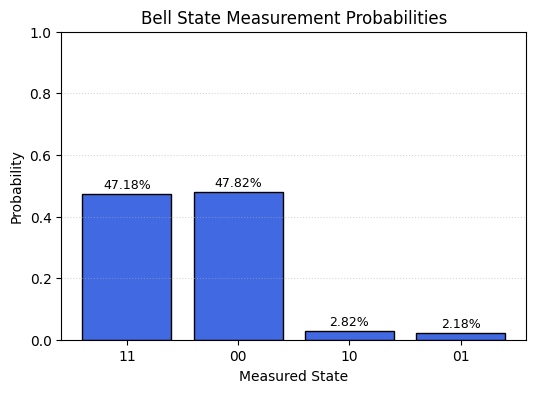

In [23]:
from qiskit_ibm_runtime import QiskitRuntimeService
import matplotlib.pyplot as plt

# Retrieve the job
retrieved_job = service.job(job.job_id())

# Check if it's already done (no waiting forever)
status = retrieved_job.status()
print(f"Job status: {status}")

if str(status) == "DONE" or str(status).endswith("DONE"):
    result = retrieved_job.result()
    counts = result[0].data.meas.get_counts()
    print(f"Measurement counts: {counts}")

    # --- Visualization ---
    states = list(counts.keys())
    values = list(counts.values())
    total_shots = sum(values)
    probabilities = [v / total_shots for v in values]

    plt.figure(figsize=(6, 4))
    bars = plt.bar(states, probabilities, color="royalblue", edgecolor="black")

    for bar, prob in zip(bars, probabilities):
        plt.text(bar.get_x() + bar.get_width() / 2, prob + 0.01,
                 f"{prob:.2%}", ha="center", va="bottom", fontsize=9)

    plt.title("Bell State Measurement Probabilities")
    plt.xlabel("Measured State")
    plt.ylabel("Probability")
    plt.ylim(0, 1)
    plt.grid(axis="y", linestyle=":", alpha=0.5)
    plt.show()

else:
    print("Job not completed yet — try again later.")
